# Multivariate Regression Covid

In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
import os
cwd = os.getcwd()
print(cwd)

c:\Users\danie\Documents\GitHub\thesis\modelling


In [68]:
df = pd.read_csv('../Data/gold/covid_multivariate_w_2.csv')
df.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [69]:
df['country'].unique()

array(['Chile', 'Colombia', 'Italy', 'Mexico', 'US'], dtype=object)

In [70]:
import json
from pathlib import Path

# path to the JSON file
json_path = Path("..") / "Data" / "gold" / "features_dict.json"

# read it into a Python dict
with json_path.open("r", encoding="utf‑8") as f:
    features_dict = json.load(f)

# quick sanity check
print(f"Loaded {len(features_dict)} keys from features_dict.json")

Loaded 2 keys from features_dict.json


In [71]:
selected_features_covid = features_dict['covid_col']

In [72]:
selected_features_covid

['new_cases', 'google_symptom', 'o3', 'pop_vaccinated', 'no2']

In [73]:
selected_features_covid.extend(['date', 'country', 'StringencyIndex_Average']) # stringency index added because of VAR and makes sense

In [102]:
selected_features_covid

['new_cases',
 'google_symptom',
 'o3',
 'pop_vaccinated',
 'no2',
 'date',
 'country',
 'StringencyIndex_Average']

# Wrangle

In [74]:
df.columns

Index(['date', 'country', 'new_cases', 'cases', 'co', 'no2', 'o3', 'pm10',
       'pm25', 'so2', 'population', 'google_physician', 'google_hospital',
       'google_pharmacy', 'google_symptom', 'Mean_distance_avg_14day_movavg',
       'StringencyIndex_Average', 'pop_vaccinated'],
      dtype='object')

In [75]:
df = df[selected_features_covid]

In [76]:
df['cases_t_1'] = df.groupby('country')['new_cases'].shift(-1)

In [77]:
# ------------------------------------------------------------------
# 1.  Sort once so groupby‑shift/rolling are correct
# ------------------------------------------------------------------
df = df.sort_values(['country', 'date']).reset_index(drop=True)

# ------------------------------------------------------------------
# 2.  Create lag‑1 and lag‑2 features for the weekly target
#     (replace 'cases_t_1' with your true target column name
#      if it differs) 
# ------------------------------------------------------------------
for lag in [1, 2]:
    df[f'cases_lag_{lag}'] = (
        df.groupby('country')['cases_t_1']
          .shift(lag)
    )

# ------------------------------------------------------------------
# 3.  Two‑period rolling mean of the *previous* weeks
#     (window=2, min_periods=1 lets the first available lag
#      propagate instead of NaN)
# ------------------------------------------------------------------
df['cases_roll_mean_2'] = (
    df.groupby('country')['cases_t_1']
      .shift(1)                      # exclude the current week
      .rolling(window=2, min_periods=1)
      .mean()
      .reset_index(level=0, drop=True)   # drop group index after rolling
)

# Optional: fill remaining NaNs after the very first week for each country
df = df.dropna(subset=['cases_t_1'])
df = df.fillna(method='bfill')   # or .fillna(0) / dropna(), as you prefer

C:\Users\danie\AppData\Local\Temp\ipykernel_27704\2134973485.py:32: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='bfill')   # or .fillna(0) / dropna(), as you prefer


In [78]:
# convert date to numeric
df['date'] = pd.to_datetime(df['date'])
df['date_numeric'] = df['date'].apply(lambda x: x.timestamp())
df['month'] = df['date'].dt.month



In [79]:
df_og = df.copy()

# Regression Framework

In [80]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

## OLS

In [81]:
from sklearn.linear_model import LinearRegression
df = df_og.copy()

    country           rmse        r2
0     Chile   14275.941876  0.325943
1  Colombia   12585.910006 -1.236240
2     Italy   52392.638820  0.889379
3    Mexico   34323.457720  0.644708
4        US  293324.024239 -0.727425
country            Chile     Colombia         Italy        Mexico  \
date                                                                
2020-03-23   2419.999998   783.000019  31258.999976   1150.000012   
2020-03-30  12041.740257  6414.439359  53008.984842  17874.767580   
2020-04-06   8503.758123  6897.054286  27746.503947  11709.875752   
2020-04-13   3947.826565 -7651.057319  10939.374397  -1828.366241   
2020-04-20   4386.310525 -6481.841571  19407.006807   3691.055287   

country                US  
date                       
2020-03-23  209572.999999  
2020-03-30  118445.204988  
2020-04-06  135778.043524  
2020-04-13  101145.545659  
2020-04-20  131086.172892  


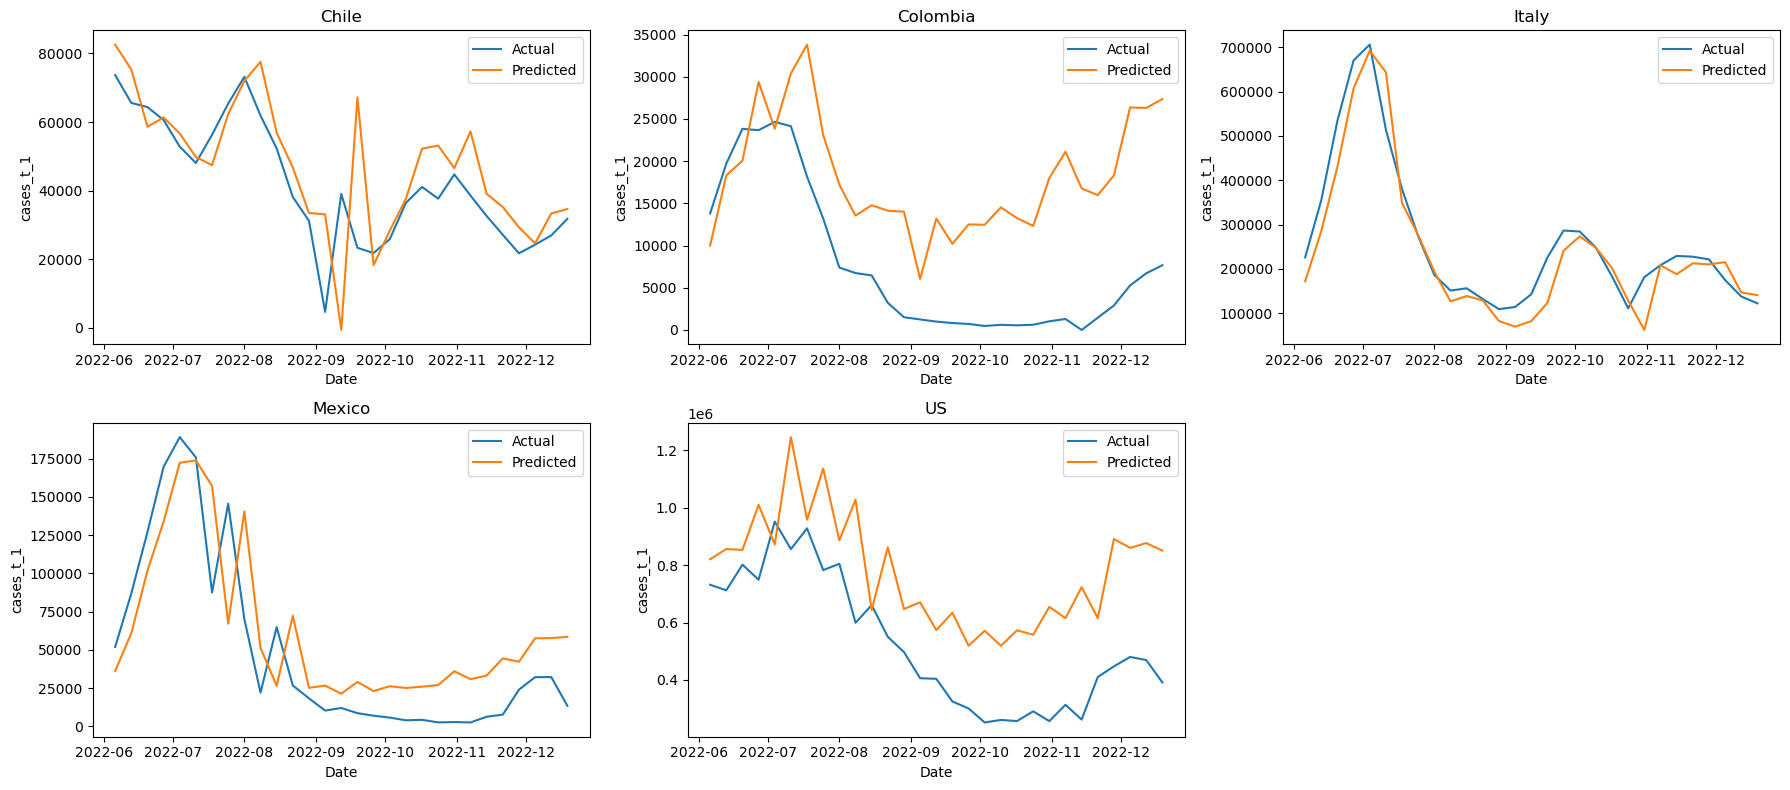

In [82]:

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # metrics per country
plot_payload  = []   # data for plotting
fit_records   = []   # date‑wise fitted values —> will pivot later

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = df_c.drop(columns=['cases_t_1', 'date'])
    X = X.select_dtypes(include='number')

    # ---- 1.3  Chronological 80 / 20 split  ---------------------
    split_pt = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Fit Linear Regression
    linreg = LinearRegression()
    linreg.fit(X_train, y_train)

    # ---- 1.5  Predict + metrics
    y_pred_test  = linreg.predict(X_test)
    y_pred_train = linreg.predict(X_train)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values for *all* rows (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table (unchanged)
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values  ← NEW
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)          # long
      .pivot(index='date', columns='country', values='fitted')  # wide
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Plot section (unchanged)
# -------------------------------------------------------------
import matplotlib.pyplot as plt
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()

In [83]:
fitted_df.to_csv('../results/OLS_covid.csv', index = True)

## Lasso

In [84]:
from sklearn.pipeline      import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model  import LassoCV
df = df_og.copy()


c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.652e+08, tolerance: 6.592e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.105e+10, tolerance: 9.662e+09
  model = cd_fast.enet_coordinate_descent(


    country           rmse        r2       alpha
0     Chile   14335.351953  0.320321   43.025587
1  Colombia    9958.353168 -0.399988  239.781924
2     Italy   50606.075317  0.896794  227.110866
3    Mexico   33839.557633  0.654655  124.534417
4        US  277227.901306 -0.543042  847.482466
country            Chile     Colombia         Italy        Mexico  \
date                                                                
2020-03-23  11205.535879  4843.936971  87802.265582   7028.192817   
2020-03-30  11237.441621  8061.391025  42496.228964  18322.112499   
2020-04-06   7945.814319  7833.760550  20335.651129  12321.125522   
2020-04-13   3623.128192 -5829.483846   2612.608857   -999.241071   
2020-04-20   4069.560892 -4369.168802  10237.949130   4406.246750   

country                US  
date                       
2020-03-23   96450.399238  
2020-03-30  144793.121946  
2020-04-06  155296.559669  
2020-04-13  115288.368510  
2020-04-20  146093.438700  


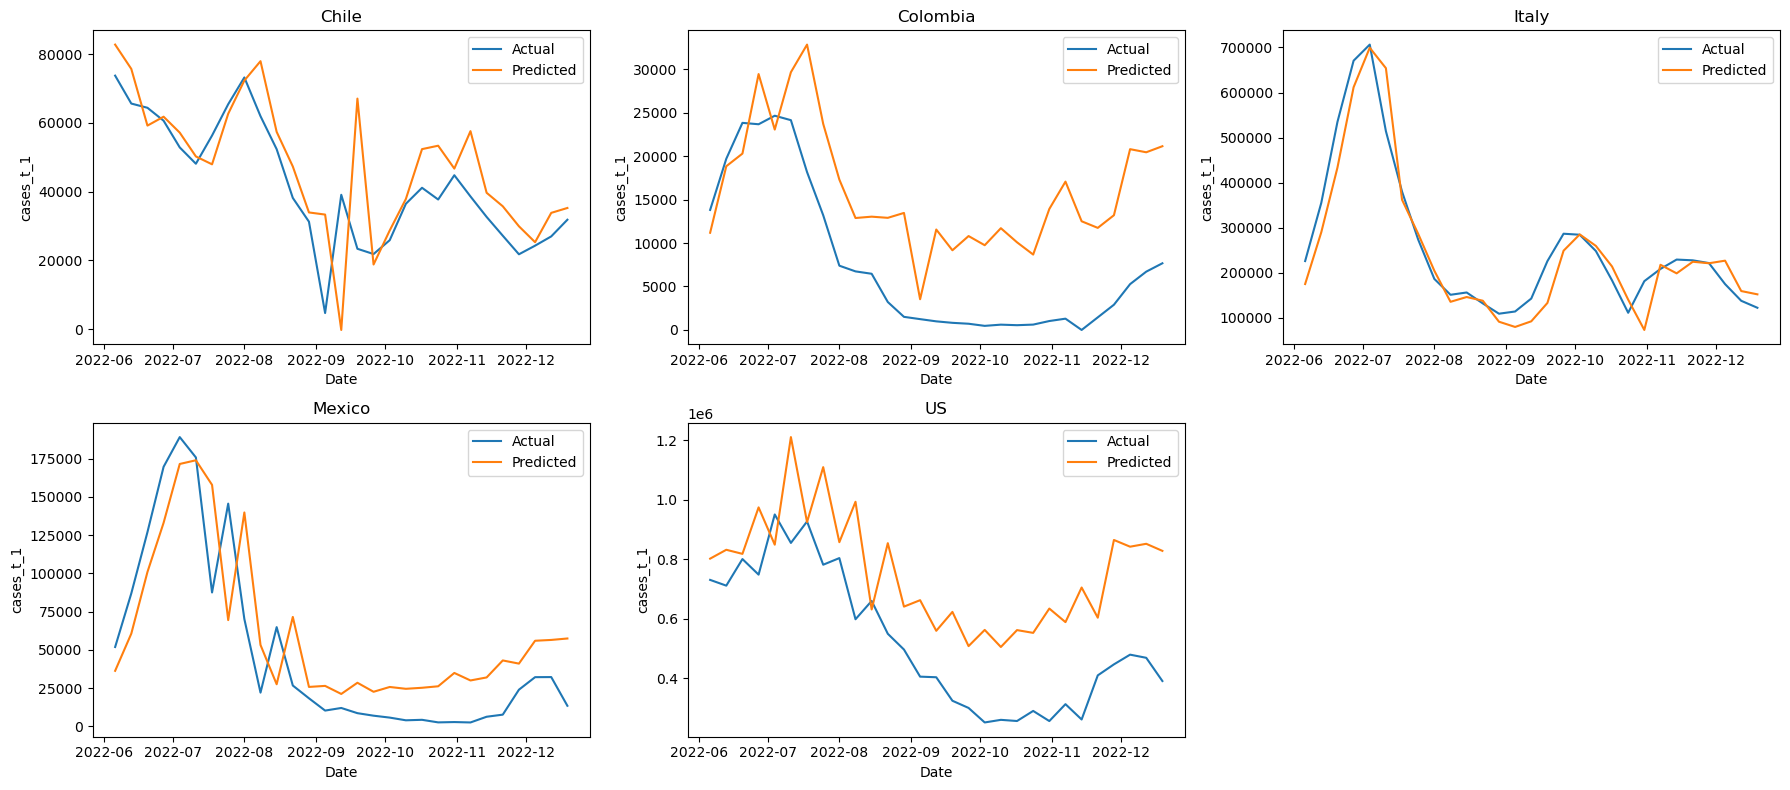

In [85]:

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = df_c.drop(columns=['cases_t_1', 'date']).select_dtypes(include='number')

    # ---- 1.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: scaler → LassoCV
    #           inner CV keeps order (3 folds on TRAIN only)
    inner_cv = TimeSeriesSplit(n_splits=3)

    lasso_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  LassoCV(cv=inner_cv,
                           random_state=42,
                           n_alphas=50,
                           max_iter=5000))
    ])

    lasso_pipe.fit(X_train, y_train)
    best_alpha = lasso_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = lasso_pipe.predict(X_test)
    y_pred_train = lasso_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)
    results.append({"country": country, "rmse": rmse, "r2": r2,
                    "alpha": best_alpha})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Plot Actual vs. Predicted (unchanged)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [86]:
# store results
fitted_df.to_csv('../results/Lasso_covid.csv', index = True)

## Ridge

In [87]:
from sklearn.linear_model  import RidgeCV
df = df_og.copy()

    country           rmse        r2     alpha
0     Chile   14692.949611  0.285989  0.004175
1  Colombia    9840.486282 -0.367043  2.043360
2     Italy   50982.591841  0.895253  0.117210
3    Mexico   34254.254545  0.646139  0.188739
4        US  293039.765517 -0.724078  0.001000
country            Chile     Colombia         Italy        Mexico  \
date                                                                
2020-03-23  10391.670218  5089.469139  85477.888040   2811.450241   
2020-03-30  10904.938282  7310.779341  46500.458543  17959.104821   
2020-04-06   7551.325389  6901.407658  22857.913567  11783.994199   
2020-04-13   3310.713079 -7760.731718   5088.199468  -1766.328307   
2020-04-20   3644.804307 -5767.251932  13092.940614   3715.719467   

country                US  
date                       
2020-03-23  205304.900002  
2020-03-30  119474.683478  
2020-04-06  136445.026002  
2020-04-13  101746.220500  
2020-04-20  131659.647722  


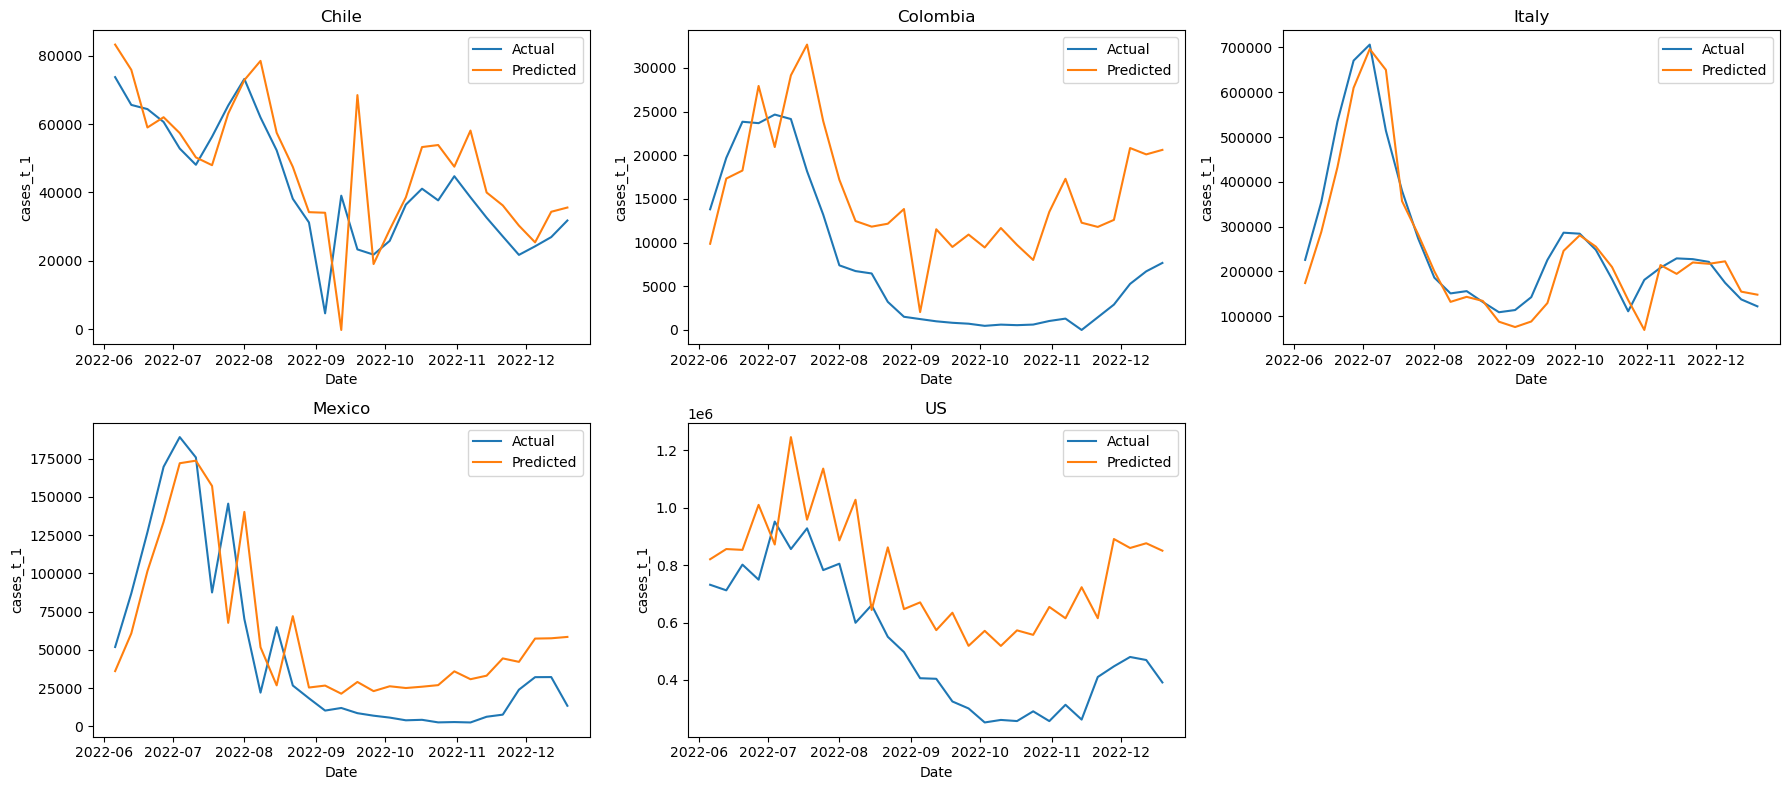

In [88]:
# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 1.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 1.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c
         .drop(columns=['cases_t_1', 'date'])
         .select_dtypes(include='number'))

    # ---- 1.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler → RidgeCV
    inner_cv = TimeSeriesSplit(n_splits=3)   # CV folds on TRAIN only
    ridge_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  RidgeCV(alphas=np.logspace(-3, 3, 30),
                           cv=inner_cv,
                           scoring='neg_root_mean_squared_error'))
    ])

    ridge_pipe.fit(X_train, y_train)
    best_alpha = ridge_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = ridge_pipe.predict(X_test)
    y_pred_train = ridge_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2,
                    "alpha": best_alpha})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )
# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Plot Actual vs. Predicted (unchanged)
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [89]:
# save the fitted values
fitted_df.to_csv('../results/Ridge_covid.csv', index = True)

## Elastic Net

In [90]:
from sklearn.linear_model  import ElasticNetCV
df = df_og.copy()

c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.082e+09, tolerance: 2.350e+07
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.630e+10, tolerance: 6.592e+08
  model = cd_fast.enet_coordinate_descent(
c:\Users\danie\anaconda3\envs\thesis\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisati

    country           rmse        r2     alpha
0     Chile   14654.810283  0.289691  0.001000
1  Colombia    8376.306183  0.009501  0.072790
2     Italy   50839.200579  0.895841  0.001000
3    Mexico   34090.814373  0.649508  0.010826
4        US  287436.047456 -0.658771  0.001000
country            Chile     Colombia         Italy        Mexico  \
date                                                                
2020-03-23  10940.211656  6710.255425  82161.669972   6180.908934   
2020-03-30  11047.608311  8340.738450  46841.848305  18168.814824   
2020-04-06   7574.065803  7373.152192  23168.475329  11965.241417   
2020-04-13   3189.373052 -7269.101460   5459.474305  -1618.538217   
2020-04-20   3495.783101 -4919.506383  13413.094356   3782.307188   

country                US  
date                       
2020-03-23  135660.838229  
2020-03-30  137194.951483  
2020-04-06  148178.305583  
2020-04-13  112339.077927  
2020-04-20  141723.947832  


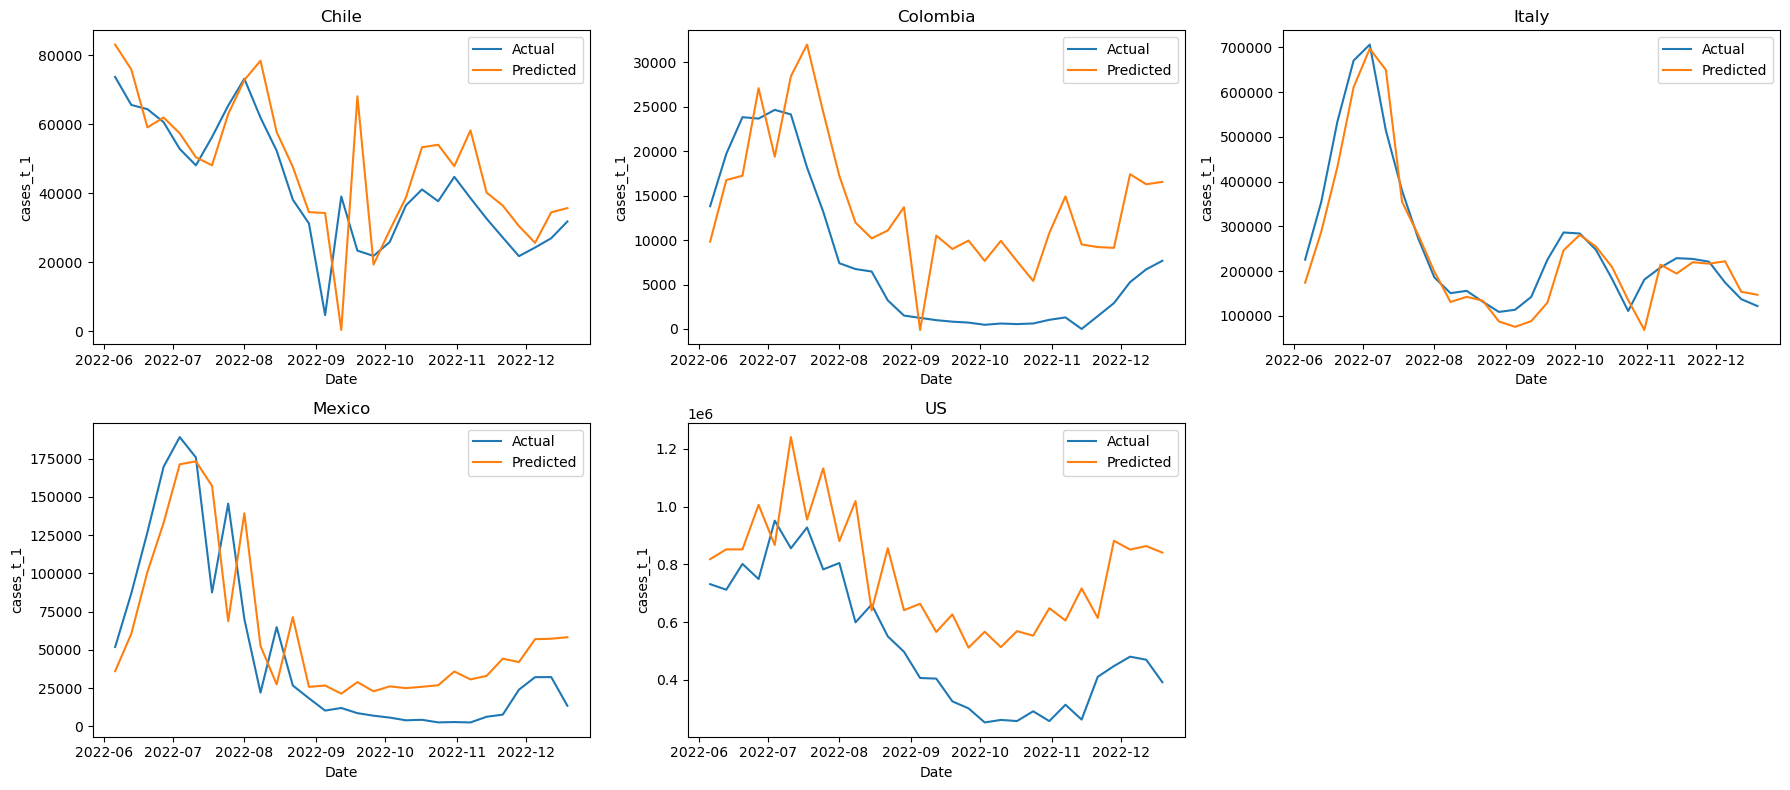

In [91]:
# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    df_c = df_c.sort_values('date').reset_index(drop=True)

    y = df_c['cases_t_1']
    X = (df_c.drop(columns=['cases_t_1', 'date'])
              .select_dtypes(include='number'))

    # ---- 1.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 1.4  Pipeline: StandardScaler → ElasticNetCV
    inner_cv = TimeSeriesSplit(n_splits=3)     # CV on TRAIN only
    enet_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  ElasticNetCV(
                      l1_ratio     = 0.5,
                      alphas       = np.logspace(-3, 3, 30),
                      cv           = inner_cv,
                      random_state = 42,
                      max_iter     = 5000))
    ])

    enet_pipe.fit(X_train, y_train)
    best_alpha = enet_pipe.named_steps["model"].alpha_

    # ---- 1.5  Predict + metrics
    y_pred_test  = enet_pipe.predict(X_test)
    y_pred_train = enet_pipe.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({"country": country, "rmse": rmse, "r2": r2,
                    "alpha": best_alpha})

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 1.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 2.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 3.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 4.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [92]:
# save fitted values
fitted_df.to_csv('../results/ElasticNet_covid.csv', index = True)

## Random Forest

In [93]:
from sklearn.model_selection import  GridSearchCV
from sklearn.ensemble      import RandomForestRegressor
df = df_og.copy()

    country           rmse        r2  \
0     Chile   15598.017310  0.195316   
1  Colombia    3056.870388  0.868082   
2     Italy   82398.788934  0.726385   
3    Mexico   41497.682949  0.480661   
4        US  125390.711548  0.684329   

                                         best_params  
0  {'bootstrap': True, 'max_depth': None, 'max_fe...  
1  {'bootstrap': False, 'max_depth': None, 'max_f...  
2  {'bootstrap': False, 'max_depth': 10, 'max_fea...  
3  {'bootstrap': False, 'max_depth': None, 'max_f...  
4  {'bootstrap': True, 'max_depth': 10, 'max_feat...  
country           Chile     Colombia         Italy       Mexico             US
date                                                                          
2020-03-23  8530.344005  1132.711069  31257.149167  4117.788656  194768.904851
2020-03-30  3675.560336  1048.312125  27401.764167  3063.787583  214779.500988
2020-04-06  3437.436956  1048.312125  22603.102083  3063.787583  200967.213993
2020-04-13  3679.164801  1388.9455

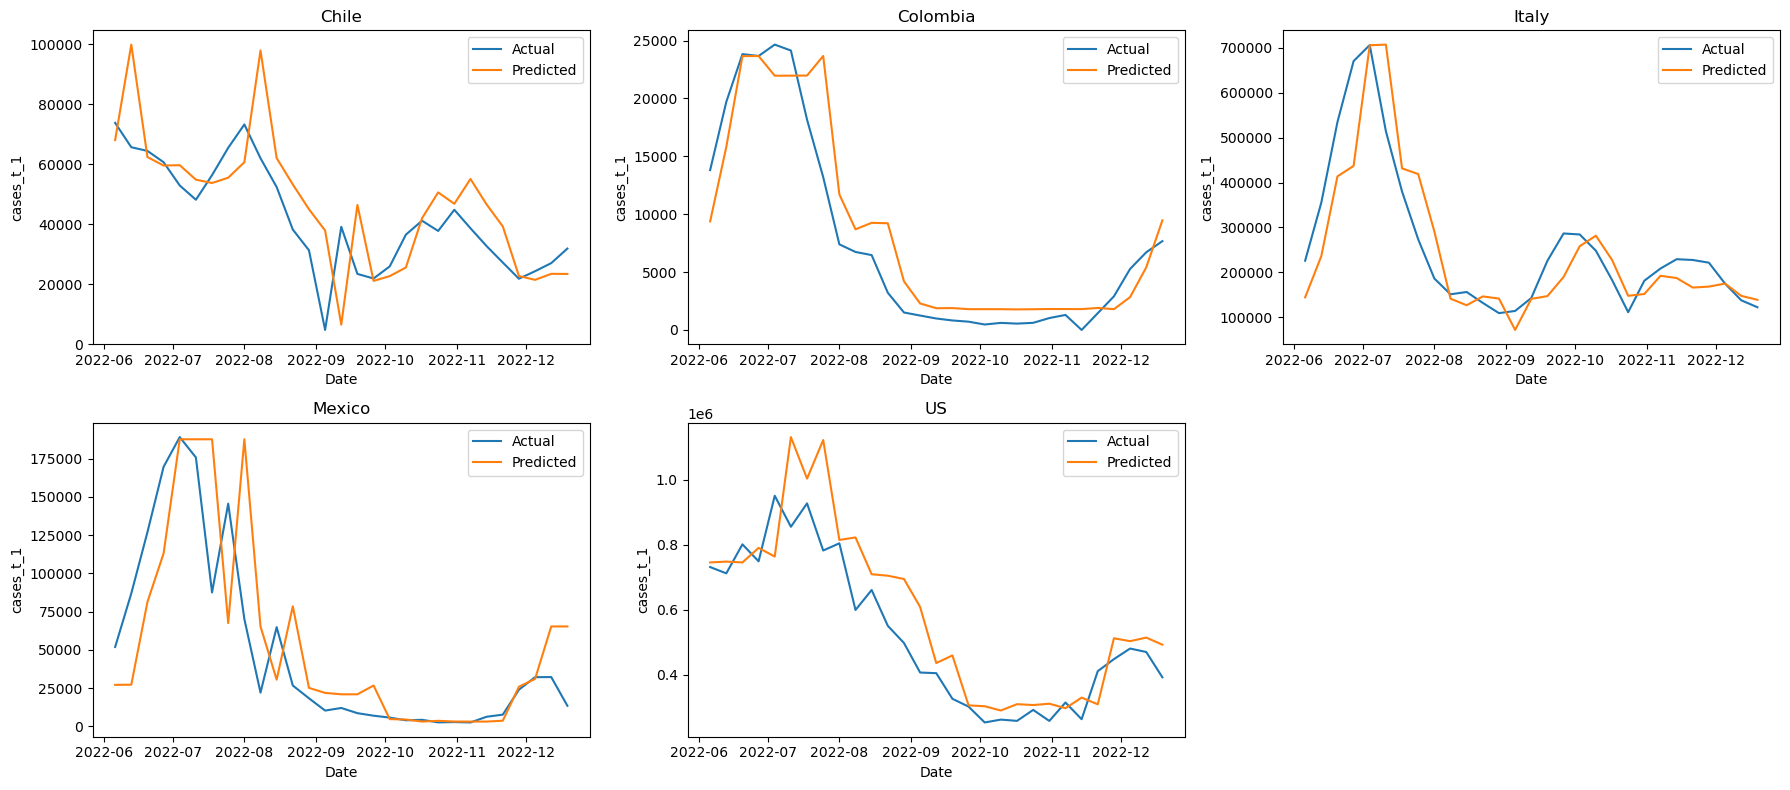

In [94]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid  (start coarse → tighten later)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":      [400, 800, 1200],
    "max_depth":         [None, 10, 20],
    "max_features":      ["sqrt", 0.6, 0.8],
    "min_samples_leaf":  [1, 3, 5],
    "bootstrap":         [True, False]
}

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 2.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 2.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c.drop(columns=['cases_t_1', 'date'])
              .select_dtypes(include='number'))

    # ---- 2.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.4  Inner CV: GridSearch over RF on TRAIN only ----
    inner_cv = TimeSeriesSplit(n_splits=3)
    rf_base  = RandomForestRegressor(random_state=42, n_jobs=-1)

    grid = GridSearchCV(
        estimator   = rf_base,
        param_grid  = param_grid,
        cv          = inner_cv,
        scoring     = "neg_root_mean_squared_error",
        n_jobs      = -1,
        verbose     = 0
    )
    grid.fit(X_train, y_train)
    best_rf     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics
    y_pred_test  = best_rf.predict(X_test)
    y_pred_train = best_rf.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": best_params
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test)
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )

# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [95]:
fitted_df.to_csv('../results/RF_covid.csv', index = True)

## Gradient Boosting

In [96]:
from sklearn.ensemble      import GradientBoostingRegressor
df = df_og.copy()

    country           rmse        r2  \
0     Chile   14960.286761  0.259770   
1  Colombia    4005.438088  0.773510   
2     Italy   79814.306932  0.743280   
3    Mexico   29691.815862  0.734125   
4        US  547902.079157 -5.027119   

                                         best_params  
0  {'learning_rate': 0.1, 'max_depth': 2, 'max_fe...  
1  {'learning_rate': 0.05, 'max_depth': 2, 'max_f...  
2  {'learning_rate': 0.05, 'max_depth': 3, 'max_f...  
3  {'learning_rate': 0.05, 'max_depth': 3, 'max_f...  
4  {'learning_rate': 0.1, 'max_depth': 4, 'max_fe...  
country            Chile     Colombia         Italy       Mexico  \
date                                                               
2020-03-23  14471.939653  3330.497672  33652.729788  1436.211874   
2020-03-30  -2363.259246  1794.872512  23703.349295  3539.520303   
2020-04-06    703.487861  1794.872512  18967.839896  4475.312376   
2020-04-13   3153.589742  2323.214326  13797.129859  6384.825538   
2020-04-20   7092.572

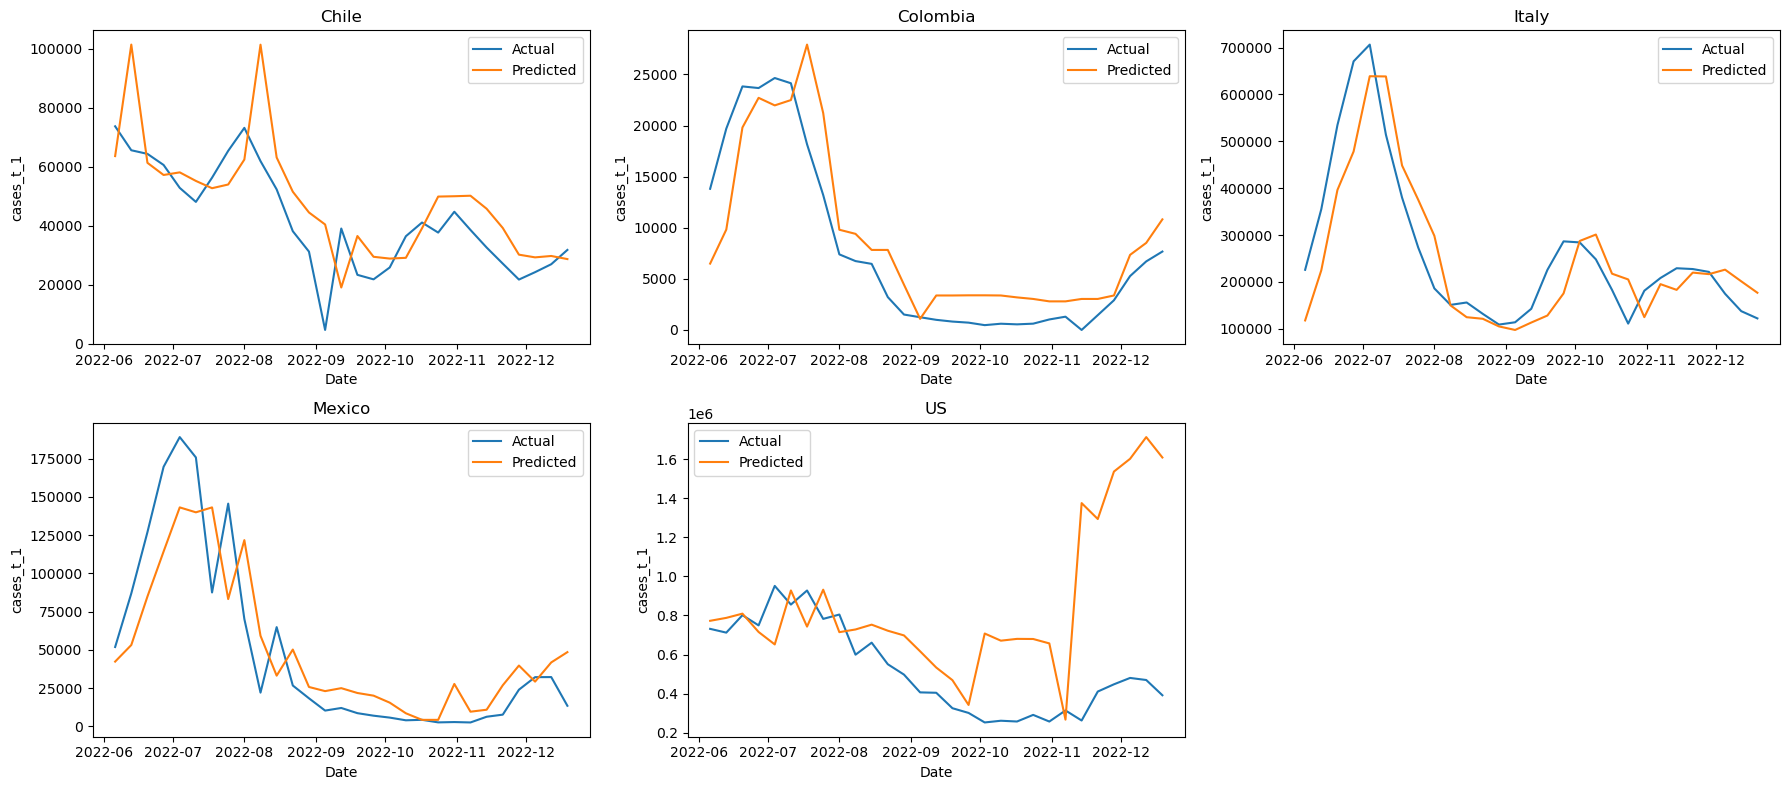

In [97]:

# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # metrics per country
plot_payload  = []   # data for hold‑out plots
fit_records   = []   # fitted values for every row

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid  (coarse → refine later)
# -------------------------------------------------------------
param_grid = {
    "n_estimators":      [200, 400, 800],
    "learning_rate":     [0.03, 0.05, 0.1],
    "max_depth":         [2, 3, 4],        # depth of individual trees
    "subsample":         [0.7, 0.9, 1.0],
    "min_samples_leaf":  [1, 3, 5],
    "max_features":      ["sqrt", 0.6, None]
}

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    df_c = df_c.sort_values('date').reset_index(drop=True)

    y = df_c['cases_t_1']
    X = (df_c.drop(columns=['cases_t_1', 'date'])
              .select_dtypes(include='number'))

    # ---- 2.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.4  Grid‑search GBM on training portion ------------
    inner_cv = TimeSeriesSplit(n_splits=3)     # folds inside TRAIN only
    gb_base  = GradientBoostingRegressor(random_state=42)

    grid = GridSearchCV(
        estimator  = gb_base,
        param_grid = param_grid,
        cv         = inner_cv,
        scoring    = "neg_root_mean_squared_error",
        n_jobs     = -1,
        verbose    = 0
    )
    grid.fit(X_train, y_train)
    best_gb     = grid.best_estimator_
    best_params = grid.best_params_

    # ---- 2.5  Predict + metrics ------------------------------
    y_pred_test  = best_gb.predict(X_test)
    y_pred_train = best_gb.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": best_params
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test) -----------
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )


# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [98]:
fitted_df.to_csv('../results/GB_covid.csv', index = True)

## SVM

In [99]:

from sklearn.svm            import SVR
df = df_og.copy()


    country           rmse        r2  \
0     Chile   25367.180745 -1.128292   
1  Colombia   20434.086922 -4.894672   
2     Italy  240410.334559 -1.329192   
3    Mexico   54514.623028  0.103749   
4        US  231752.493630 -0.078333   

                                         best_params  
0  {'model__C': 20, 'model__epsilon': 0.2, 'model...  
1  {'model__C': 20, 'model__epsilon': 0.05, 'mode...  
2  {'model__C': 20, 'model__epsilon': 0.05, 'mode...  
3  {'model__C': 20, 'model__epsilon': 0.05, 'mode...  
4  {'model__C': 20, 'model__epsilon': 0.05, 'mode...  
country            Chile      Colombia         Italy        Mexico  \
date                                                                 
2020-03-23  19507.576935  36379.250879  62397.050315  36650.089231   
2020-03-30  17356.069579  35966.152887  61929.789935  34150.251702   
2020-04-06  16715.259174  36352.520001  61206.526293  33724.318735   
2020-04-13  16223.207141  34385.158059  59492.732648  32633.701045   
2020-04-2

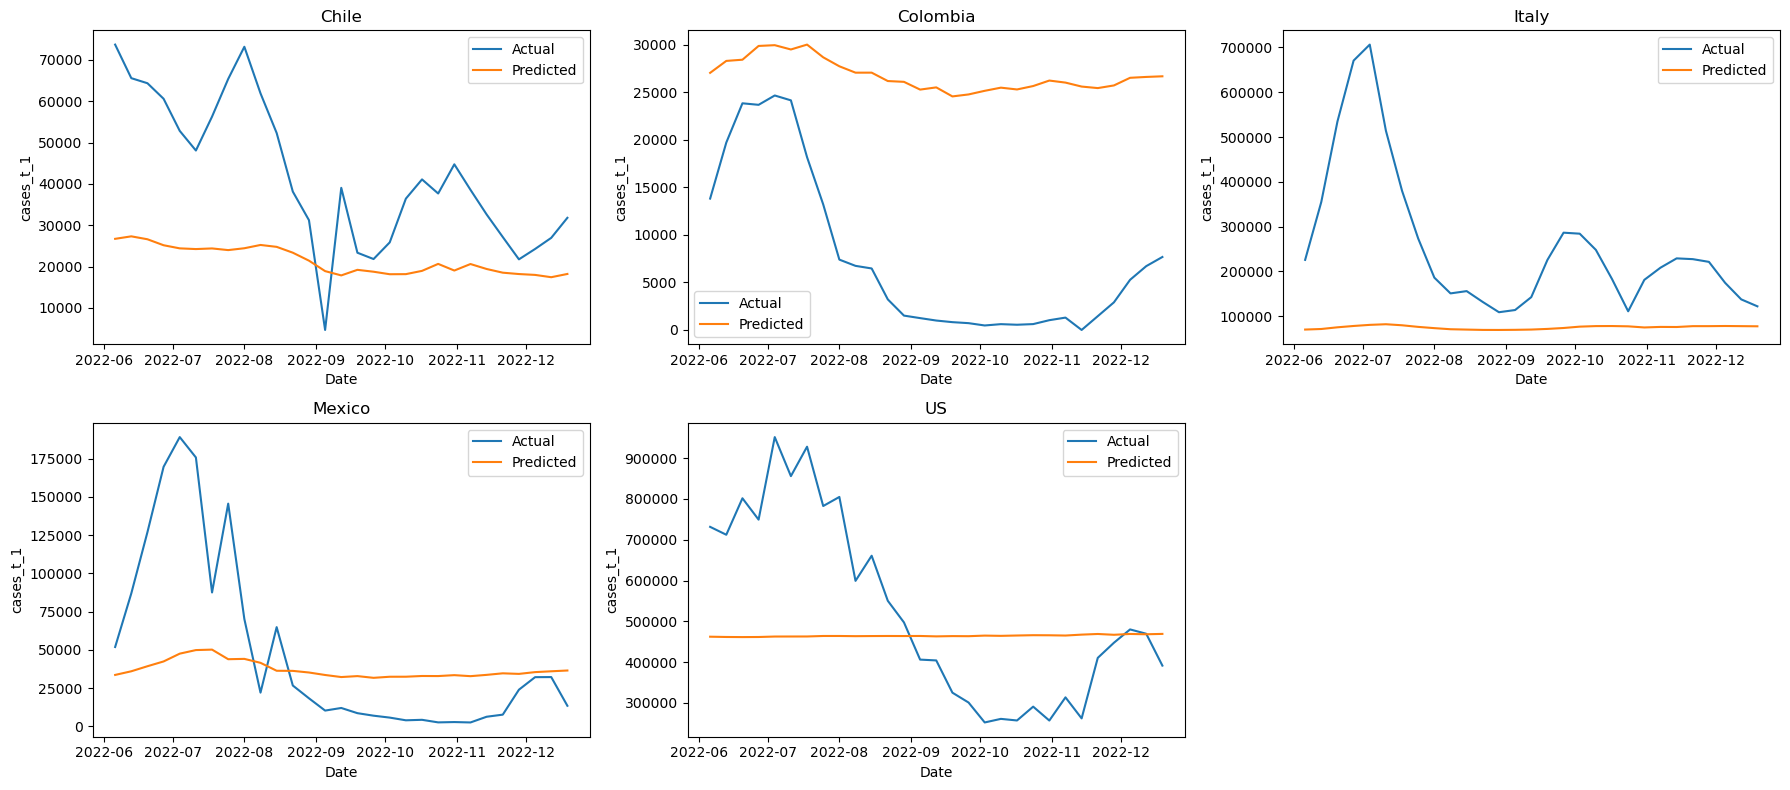

In [100]:


# -------------------------------------------------------------
# 0.  Ensure 'date' is datetime
# -------------------------------------------------------------
df['date'] = pd.to_datetime(df['date'])

results       = []   # per‑country metrics
plot_payload  = []   # hold‑out curves
fit_records   = []   # fitted values (train + test)

# -------------------------------------------------------------
# 1.  Hyper‑parameter grid for SVR with an RBF kernel
#    (γ = 1 / (2σ²) in the RBF; tune together with C, ε)
# -------------------------------------------------------------
param_grid = [
    {   # RBF search
        "model__kernel":  ["rbf"],
        "model__C":       [0.5, 1, 5, 20],
        "model__epsilon": [0.05, 0.1, 0.2],
        "model__gamma":   ["scale", 0.01, 0.1, 1.0],
    },
    {   # Linear search (no gamma)
        "model__kernel":  ["linear"],
        "model__C":       [0.5, 1, 5, 20],
        "model__epsilon": [0.05, 0.1, 0.2],
    },
]

# -------------------------------------------------------------
# 2.  Loop over countries
# -------------------------------------------------------------
for country, df_c in df.groupby('country'):

    # ---- 2.1  Chronological order
    df_c = df_c.sort_values('date').reset_index(drop=True)

    # ---- 2.2  Split features / target
    y = df_c['cases_t_1']
    X = (df_c.drop(columns=['cases_t_1', 'date'])
              .select_dtypes(include='number'))

    # ---- 2.3  Chronological 80 / 20 split --------------------
    split_pt  = int(0.80 * len(df_c))          # oldest 80 % → train
    train_idx = np.arange(split_pt)
    test_idx  = np.arange(split_pt, len(df_c))

    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    dates_test      = df_c.loc[test_idx, 'date']

    # ---- 2.4  Pipeline: StandardScaler → SVR -----------------
    inner_cv = TimeSeriesSplit(n_splits=3)     # CV folds on TRAIN only
    svr_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("model",  SVR())          # RBF to match the grid
    ])

    grid = GridSearchCV(
        estimator  = svr_pipe,
        param_grid = param_grid,
        cv         = inner_cv,
        scoring    = "neg_root_mean_squared_error",
        n_jobs     = -1,
        verbose    = 0
    )
    grid.fit(X_train, y_train)

    best_svr     = grid.best_estimator_
    best_params  = grid.best_params_

    # ---- 2.5  Predict + metrics ------------------------------
    y_pred_test  = best_svr.predict(X_test)
    y_pred_train = best_svr.predict(X_train)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2   = r2_score(y_test, y_pred_test)

    results.append({
        "country":     country,
        "rmse":        rmse,
        "r2":          r2,
        "best_params": best_params
    })

    plot_payload.append({
        "country": country,
        "date":    dates_test,
        "y_true":  y_test,
        "y_pred":  y_pred_test
    })

    # ---- 2.6  Collect fitted values (train + test) -----------
    y_hat_full = pd.Series(index=df_c.index, dtype=float)
    y_hat_full.iloc[train_idx] = y_pred_train
    y_hat_full.iloc[test_idx]  = y_pred_test

    fit_records.append(
        pd.DataFrame({
            "date":    df_c['date'],
            "country": country,
            "fitted":  y_hat_full.values
        })
    )


# -------------------------------------------------------------
# 3.  Metrics table
# -------------------------------------------------------------
metrics_df = pd.DataFrame(results)
print(metrics_df)

# -------------------------------------------------------------
# 4.  Wide DataFrame of fitted values
# -------------------------------------------------------------
fitted_df = (
    pd.concat(fit_records)
      .pivot(index='date', columns='country', values='fitted')
      .sort_index()
)
print(fitted_df.head())

# -------------------------------------------------------------
# 5.  Actual vs. Predicted plots
# -------------------------------------------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 8), sharex=False, sharey=False)
axes = axes.flatten()

for idx, payload in enumerate(plot_payload):
    ax = axes[idx]
    ax.plot(payload["date"], payload["y_true"], label="Actual")
    ax.plot(payload["date"], payload["y_pred"], label="Predicted")
    ax.set_title(payload["country"])
    ax.set_xlabel("Date")
    ax.set_ylabel("cases_t_1")
    ax.legend()

for j in range(len(plot_payload), len(axes)):
    axes[j].axis("off")

fig.tight_layout()
plt.show()


In [101]:
fitted_df.to_csv('../results/SVM_covid.csv', index = True)